## Setup

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats
from statsmodels.stats.power import TTestIndPower
from scipy.stats import mannwhitneyu

In [2]:
df = pd.read_csv('./data/day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


## Data Exploration

### Time-wise analysis

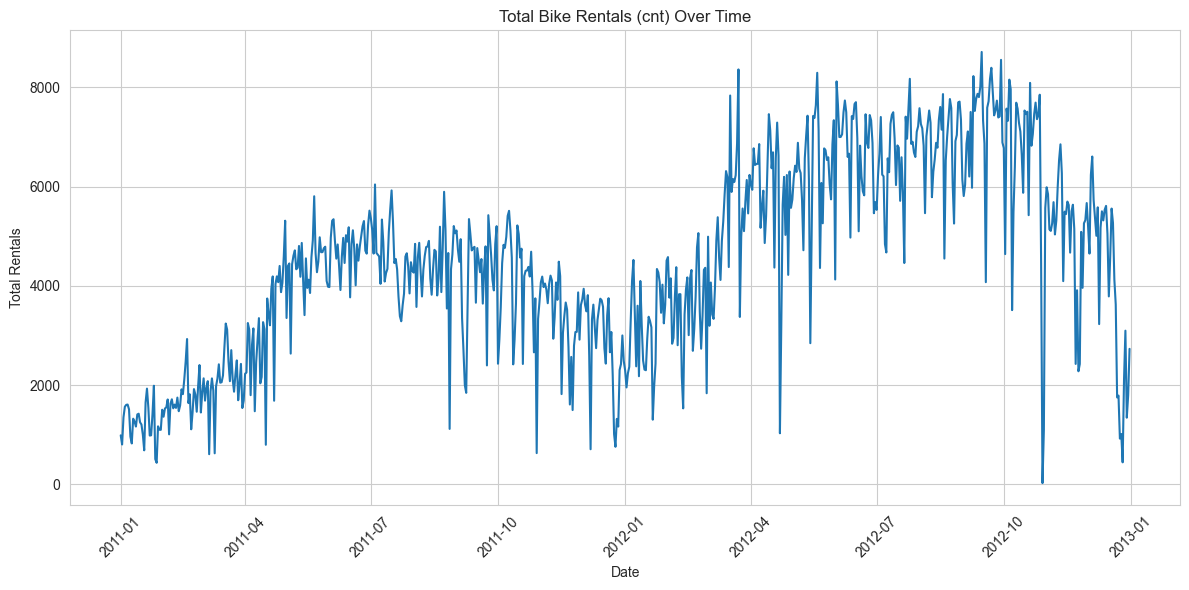

In [3]:
df['dteday'] = pd.to_datetime(df['dteday'])

plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")
sns.lineplot(x='dteday', y='cnt', data=df)
plt.title('Total Bike Rentals (cnt) Over Time')
plt.xlabel('Date')
plt.ylabel('Total Rentals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Season Analysis
Plotting average total bike rentals ('cnt') by 'season' and 'mnth' (month) to understand variation

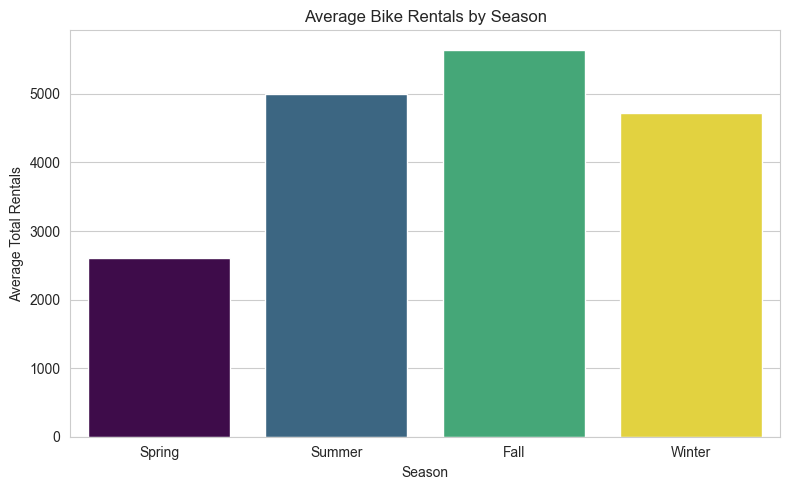

In [4]:
avg_rentals_by_season = df.groupby('season')['cnt'].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=avg_rentals_by_season.index, y=avg_rentals_by_season.values, palette='viridis', hue=avg_rentals_by_season.index, legend=False)
plt.title('Average Bike Rentals by Season')
plt.xlabel('Season')
plt.ylabel('Average Total Rentals')
plt.xticks(ticks=[0, 1, 2, 3], labels=['Spring', 'Summer', 'Fall', 'Winter'])
plt.tight_layout()
plt.show()

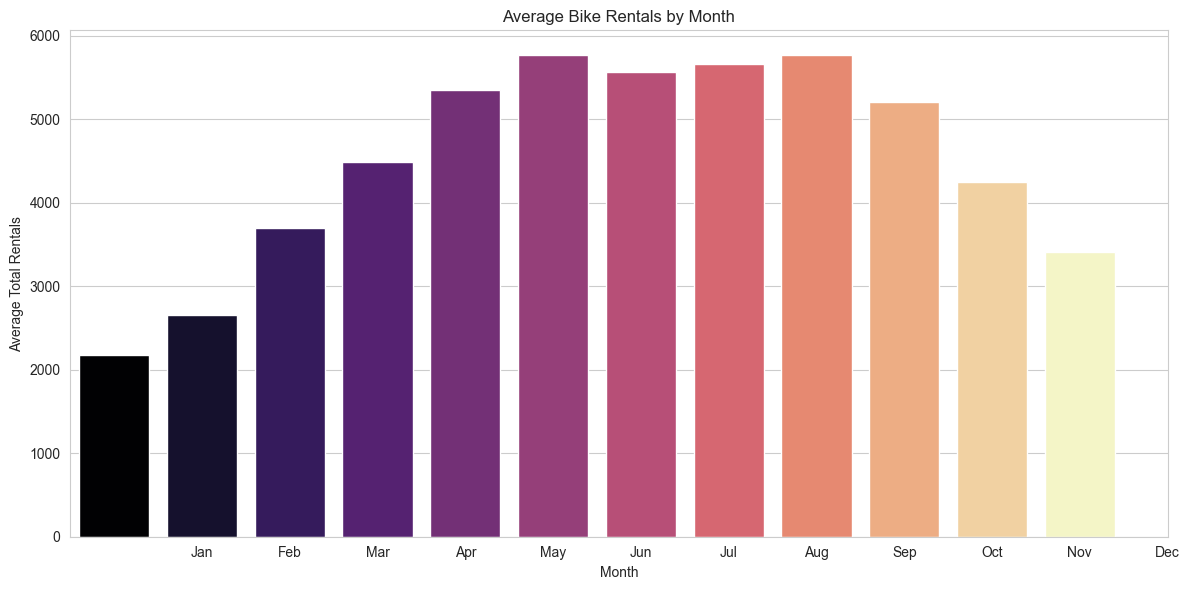

In [5]:
avg_rentals_by_month = df.groupby('mnth')['cnt'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=avg_rentals_by_month.index, y=avg_rentals_by_month.values, palette='magma', hue=avg_rentals_by_month.index, legend=False)
plt.title('Average Bike Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Total Rentals')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.tight_layout()
plt.show()

### Investigate Weather Impact

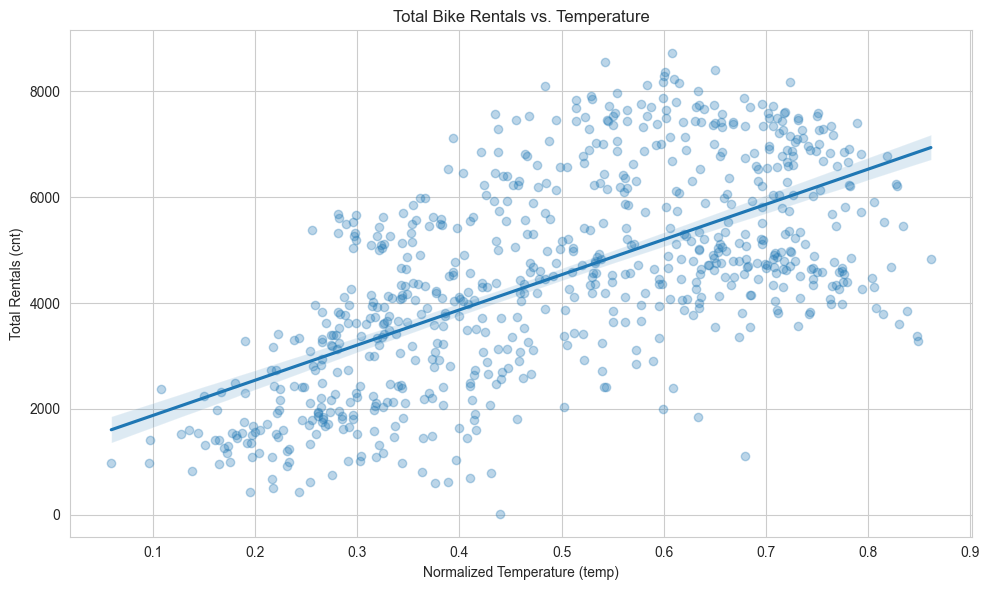

In [6]:
# Scatter plot for Temperature vs. Total Rentals
plt.figure(figsize=(10, 6))
sns.regplot(x='temp', y='cnt', data=df, scatter_kws={'alpha':0.3})
plt.title('Total Bike Rentals vs. Temperature')
plt.xlabel('Normalized Temperature (temp)')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.show()

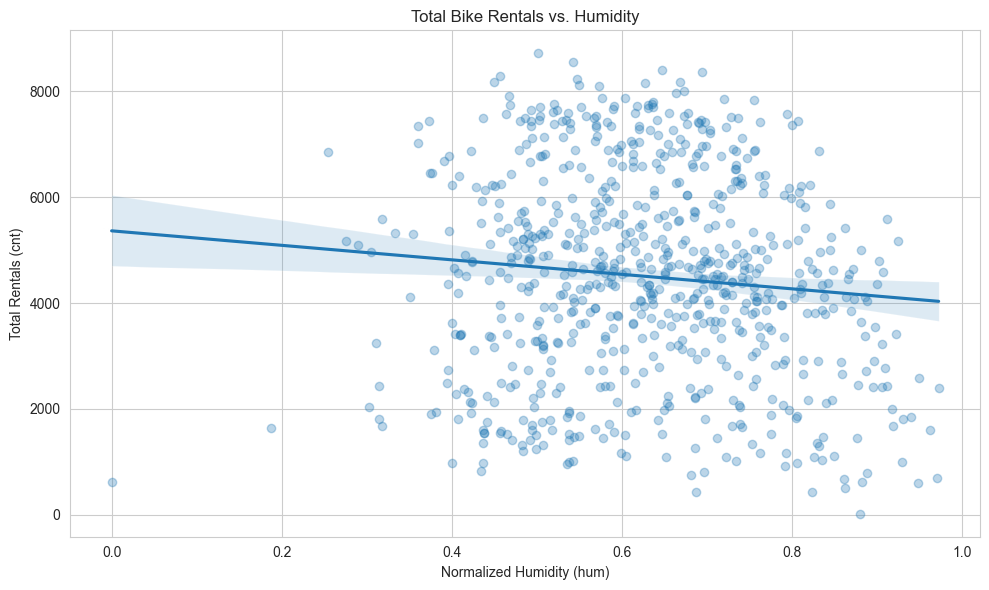

In [7]:
# Scatter plot for Humidity vs. Total Rentals
plt.figure(figsize=(10, 6))
sns.regplot(x='hum', y='cnt', data=df, scatter_kws={'alpha':0.3})
plt.title('Total Bike Rentals vs. Humidity')
plt.xlabel('Normalized Humidity (hum)')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.show()

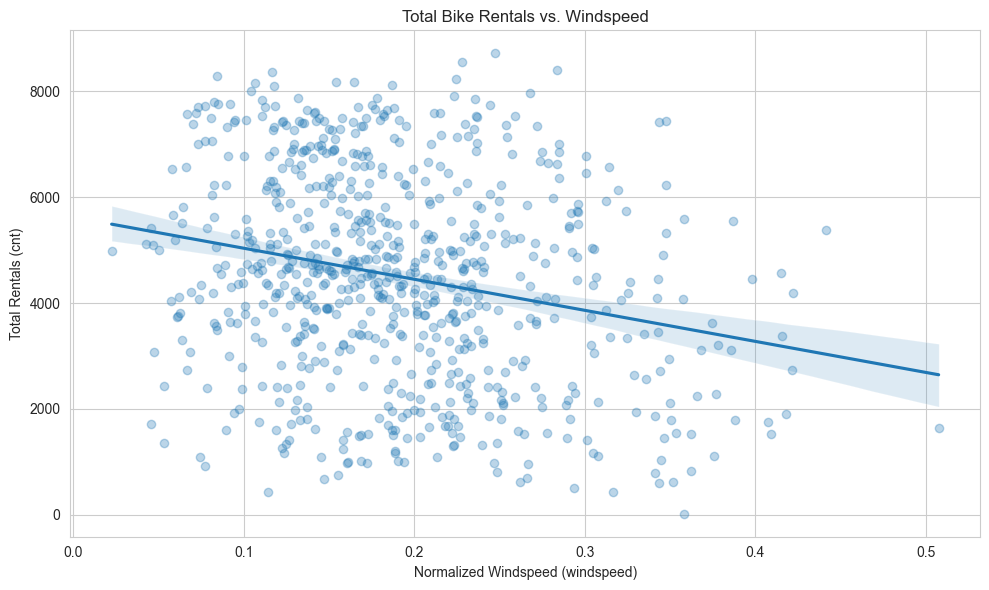

In [8]:
# Scatter plot for Windspeed vs. Total Rentals
plt.figure(figsize=(10, 6))
sns.regplot(x='windspeed', y='cnt', data=df, scatter_kws={'alpha':0.3})
plt.title('Total Bike Rentals vs. Windspeed')
plt.xlabel('Normalized Windspeed (windspeed)')
plt.ylabel('Total Rentals (cnt)')
plt.tight_layout()
plt.show()

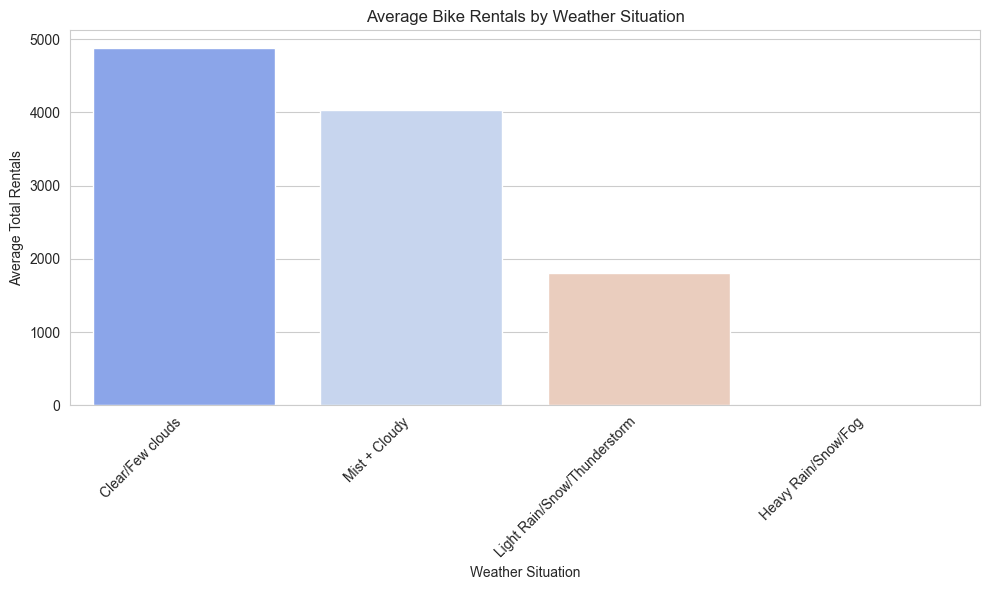

In [9]:
# Define mapping for 'weathersit' for better readability
weather_labels = {
    1: 'Clear/Few clouds',
    2: 'Mist + Cloudy',
    3: 'Light Rain/Snow/Thunderstorm',
    4: 'Heavy Rain/Snow/Fog'
}

# Apply mapping to create a new column with descriptive labels
df['weathersit_label'] = df['weathersit'].map(weather_labels)

# Group by 'weathersit_label' and calculate mean of 'cnt'
avg_rentals_by_weathersit = df.groupby('weathersit_label')['cnt'].mean().reindex(weather_labels.values())

# Create the bar plot for average rentals by weather situation
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rentals_by_weathersit.index, y=avg_rentals_by_weathersit.values, palette='coolwarm', hue=avg_rentals_by_weathersit.index, legend=False)
plt.title('Average Bike Rentals by Weather Situation')
plt.xlabel('Weather Situation')
plt.ylabel('Average Total Rentals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Examine Day Type Influence


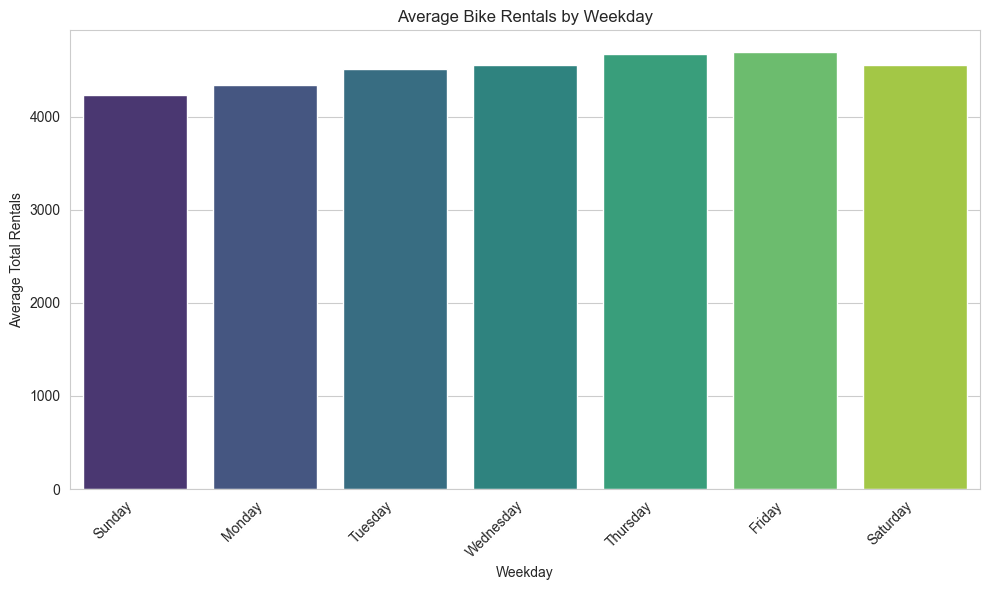

In [10]:
# Map numerical weekday to descriptive names
weekday_labels = {0: 'Sunday', 1: 'Monday', 2: 'Tuesday', 3: 'Wednesday', 4: 'Thursday', 5: 'Friday', 6: 'Saturday'}
df['weekday_label'] = df['weekday'].map(weekday_labels)
# 1. Average Bike Rentals by Weekday
avg_rentals_by_weekday = df.groupby('weekday_label')['cnt'].mean().reindex(weekday_labels.values())
plt.figure(figsize=(10, 6))
sns.barplot(x=avg_rentals_by_weekday.index, y=avg_rentals_by_weekday.values, palette='viridis', hue=avg_rentals_by_weekday.index, legend=False)
plt.title('Average Bike Rentals by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Total Rentals')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

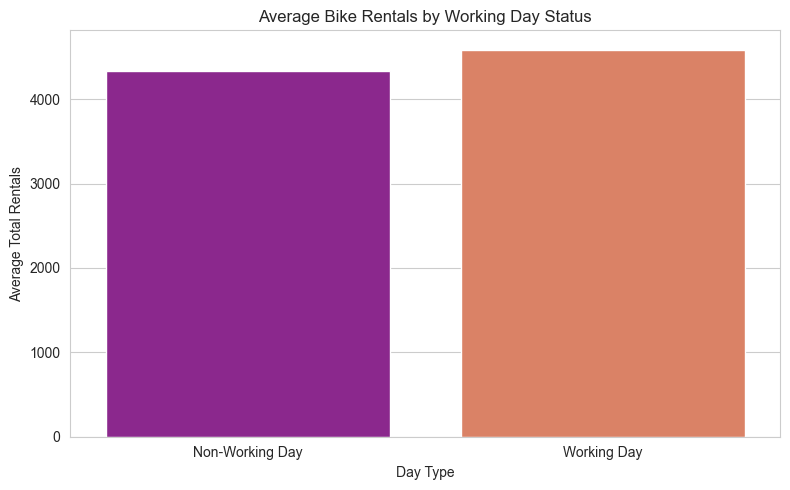

In [11]:
# 2. Average Bike Rentals by Workingday
workingday_labels = {0: 'Non-Working Day', 1: 'Working Day'}
df['workingday_label'] = df['workingday'].map(workingday_labels)
avg_rentals_by_workingday = df.groupby('workingday_label')['cnt'].mean().reindex(workingday_labels.values())
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_rentals_by_workingday.index, y=avg_rentals_by_workingday.values, palette='plasma', hue=avg_rentals_by_workingday.index, legend=False)
plt.title('Average Bike Rentals by Working Day Status')
plt.xlabel('Day Type')
plt.ylabel('Average Total Rentals')
plt.tight_layout()
plt.show()

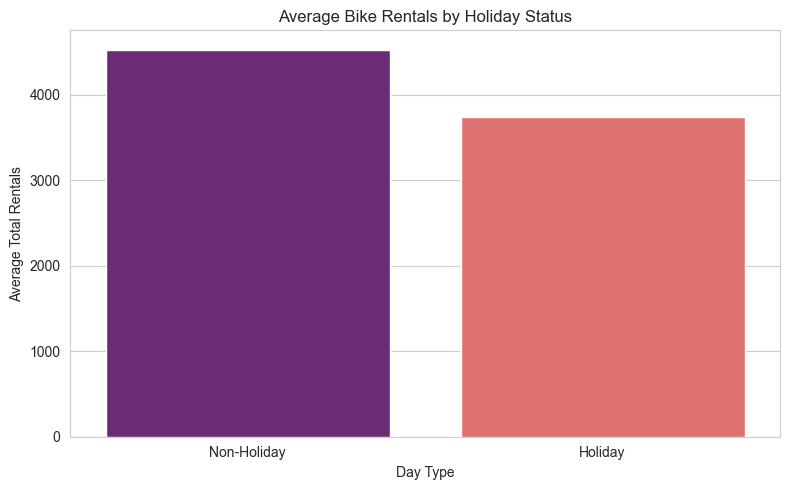

In [12]:
# 3. Average Bike Rentals by Holiday
holiday_labels = {0: 'Non-Holiday', 1: 'Holiday'}
df['holiday_label'] = df['holiday'].map(holiday_labels)
avg_rentals_by_holiday = df.groupby('holiday_label')['cnt'].mean().reindex(holiday_labels.values())
plt.figure(figsize=(8, 5))
sns.barplot(x=avg_rentals_by_holiday.index, y=avg_rentals_by_holiday.values, palette='magma', hue=avg_rentals_by_holiday.index, legend=False)
plt.title('Average Bike Rentals by Holiday Status')
plt.xlabel('Day Type')
plt.ylabel('Average Total Rentals')
plt.tight_layout()
plt.show()

### Casual vs Registered

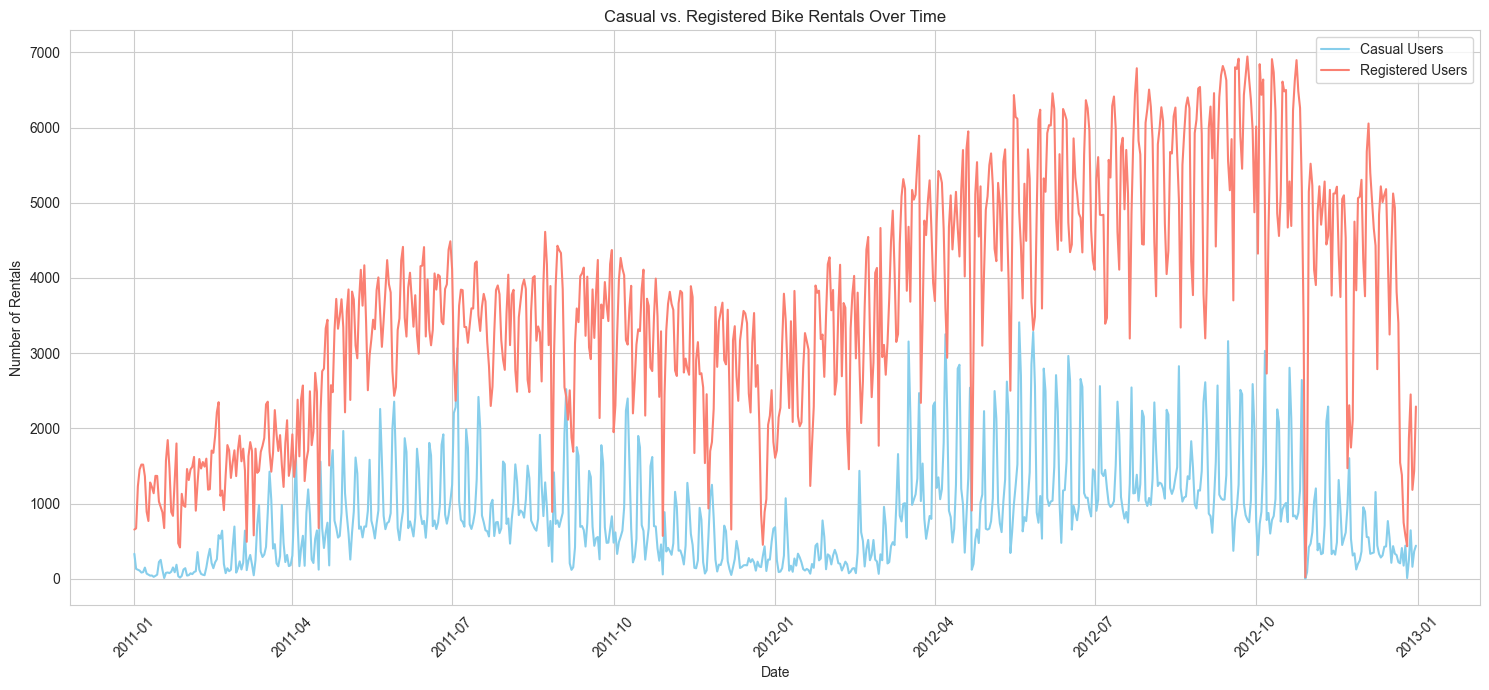

In [14]:
plt.figure(figsize=(15, 7))
sns.lineplot(x='dteday', y='casual', data=df, label='Casual Users', color='skyblue')
sns.lineplot(x='dteday', y='registered', data=df, label='Registered Users', color='salmon')
plt.title('Casual vs. Registered Bike Rentals Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Rentals')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

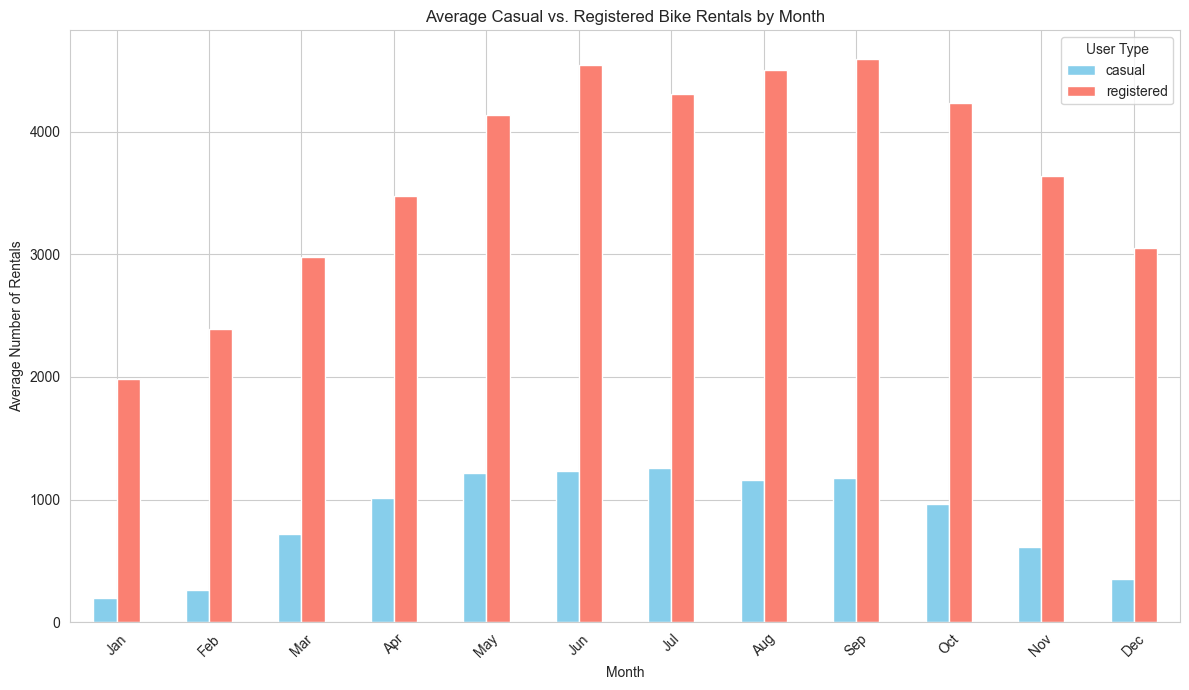

In [15]:
avg_rentals_by_month_users = df.groupby('mnth')[['casual', 'registered']].mean().reset_index()

plt.figure(figsize=(12, 7))
avg_rentals_by_month_users.set_index('mnth').plot(kind='bar', figsize=(12, 7), color=['skyblue', 'salmon'])
plt.title('Average Casual vs. Registered Bike Rentals by Month')
plt.xlabel('Month')
plt.ylabel('Average Number of Rentals')
plt.xticks(ticks=range(12), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'], rotation=45)
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

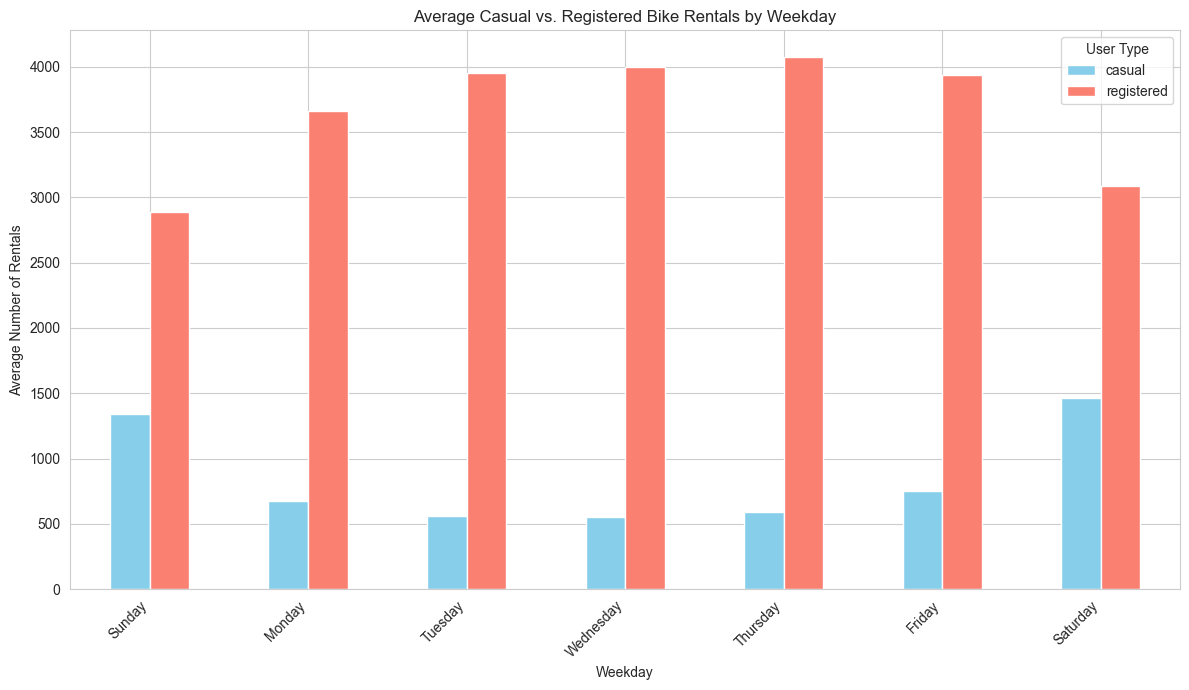

In [16]:
avg_rentals_by_weekday_users = df.groupby('weekday_label')[['casual', 'registered']].mean().reindex(weekday_labels.values())

plt.figure(figsize=(12, 7))
avg_rentals_by_weekday_users.plot(kind='bar', figsize=(12, 7), color=['skyblue', 'salmon'])
plt.title('Average Casual vs. Registered Bike Rentals by Weekday')
plt.xlabel('Weekday')
plt.ylabel('Average Number of Rentals')
plt.xticks(rotation=45, ha='right')
plt.legend(title='User Type')
plt.tight_layout()
plt.show()

### Summary:




#### Q&A
The most influential factors affecting bike rentals are:
*   **Temperature:** There is a strong positive correlation, with higher temperatures leading to significantly more rentals.
*   **Weather Situation:** Clear/few clouds result in the highest rentals, while heavy rain/snow/fog drastically reduces them.
*   **Season:** Summer and Fall seasons show the highest rental numbers.
*   **Month:** Peak rentals occur between May and October.
*   **User Type:** Registered users consistently dominate rental volumes, contributing significantly more than casual users across all periods.
*   **Working Day Status:** Bike rentals are generally higher on working days than on non-working days for registered users, while casual users show a relatively higher proportion of their rentals on weekends.


#### Data Analysis Key Findings
*   **Seasonal Trends:** Bike rentals exhibit strong seasonal patterns, peaking during the summer and fall seasons. Specifically, average rentals are highest in Summer and Fall, followed by Winter and Spring. Monthly data shows a peak in demand from May through October, with August having one of the highest average daily rentals.
*   **Temperature Impact:** A strong positive correlation exists between temperature and total bike rentals, indicating that warmer weather significantly drives up demand.
*   **Humidity Impact:** While a wide range of humidity levels support high rentals, extremely high humidity tends to correlate with a decrease in the maximum number of rentals.
*   **Windspeed Impact:** There is a negative correlation between windspeed and bike rentals; as windspeed increases, rentals generally decrease.
*   **Weather Situation Impact:**
    *   Clear weather conditions (`Clear/Few clouds`) consistently yield the highest average bike rentals.
    *   `Mist + Cloudy` conditions also see high rentals, though slightly less than clear conditions.
    *   `Light Rain/Snow/Thunderstorm` severely reduces rentals.
    *   `Heavy Rain/Snow/Fog` results in the lowest average rentals, significantly hindering bike usage.
*   **Day Type Influence:**
    *   **Weekdays vs. Weekends:** Rentals are generally higher on weekdays (especially Thursday and Friday) compared to weekends, driven mainly by registered users. Sundays generally have the lowest average rentals.
    *   **Working Day Status:** Average rentals are higher on working days than on non-working days.
    *   **Holiday Status:** Non-holidays have significantly higher average rentals than holidays.
*   **User Type Contribution:** Registered users consistently account for a much larger proportion of total rentals than casual users across all observed periods (daily, monthly, and weekly). While both user types follow similar seasonal patterns, registered users' rental volume is substantially higher. Casual users show a relatively higher proportion of their total rentals occurring on weekends compared to their weekday activity, suggesting a recreational usage pattern.

## Part A

In [18]:
work_rentals = df[df['workingday'] == 1]['cnt']
nonwork_rentals = df[df['workingday'] == 0]['cnt']

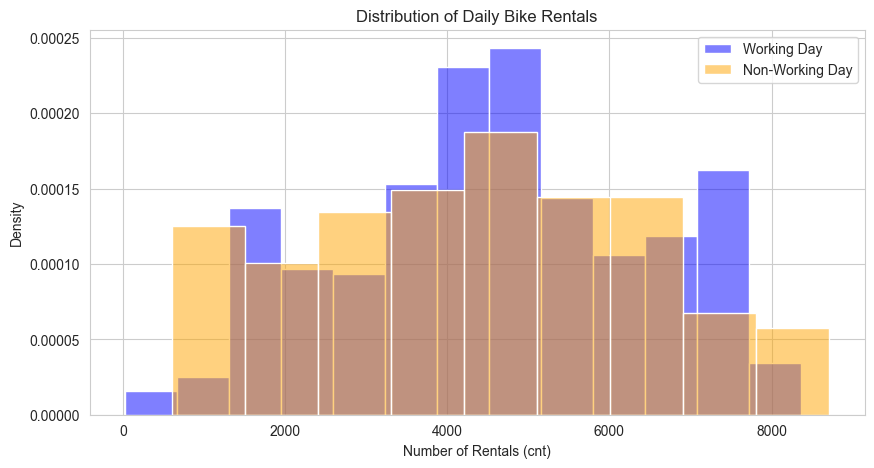

In [19]:
# EDA: Plotting the distributions to check for skew/outliers
plt.figure(figsize=(10, 5))
sns.histplot(work_rentals, color='blue', label='Working Day', stat='density', alpha=0.5)
sns.histplot(nonwork_rentals, color='orange', label='Non-Working Day', stat='density', alpha=0.5)
plt.title('Distribution of Daily Bike Rentals')
plt.xlabel('Number of Rentals (cnt)')
plt.legend()
plt.show()

### 95% Confidence Interval

In [36]:
def mean_diff(x, y):
    return np.mean(x) - np.mean(y)

# Calculate the 95% confidence interval using scipy's bootstrap
bootstrap_ci = stats.bootstrap((work_rentals, nonwork_rentals),
                               statistic=mean_diff,
                               confidence_level=0.95,
                               method='BCa',
                               random_state=42)

print(f"95% Bootstrap CI for difference in means: [{bootstrap_ci.confidence_interval.low:.4f}, {bootstrap_ci.confidence_interval.high:.4f}]")


95% Bootstrap CI for difference in means: [-55.3505, 570.0517]


### Cohen's d \& Hedge's g

In [37]:
n1, n2 = len(work_rentals), len(nonwork_rentals)
var1, var2 = np.var(work_rentals, ddof=1), np.var(nonwork_rentals, ddof=1)

# Pooled standard deviation
pooled_sd = np.sqrt(((n1 - 1) * var1 + (n2 - 1) * var2) / (n1 + n2 - 2))

cohens_d = (np.mean(work_rentals) - np.mean(nonwork_rentals)) / pooled_sd

correction_factor = 1 - (3 / (4 * (n1 + n2) - 9))
hedges_g = cohens_d * correction_factor

print(f"Cohen's d = {cohens_d:.4f}")
print(f"Hedges' g = {hedges_g:.4f}")

Cohen's d = 0.1316
Hedges' g = 0.1315


### A Standard Test: Welch t-test

In [20]:
t_stat, p_val_t = stats.ttest_ind(work_rentals, nonwork_rentals, equal_var=False)
print(f"Welch's t-test: t-statistic = {t_stat:.4f}, p-value = {p_val_t:.4e}")

Welch's t-test: t-statistic = 1.6014, p-value = 1.1006e-01


In [27]:
alpha = 0.05
print(p_val_t <= alpha, p_val_t, alpha)
if p_val_t <= alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

False 0.11005737827017054 0.05
Fail to reject H0


In [57]:
alpha = 0.05
power = 0.8
target_delta = 500
 
required_n_welch = TTestIndPower().solve_power(
    effect_size=(target_delta / pooled_sd), power=power, 
    alpha=alpha, ratio=1.0, 
    alternative='two-sided')

print(f"Required Sample Size: {required_n_welch:.2f} (approx. {int(np.ceil(required_n_welch))})",)

Required Sample Size: 236.05 (approx. 237)


### Non-param / distribution free test: Mann-Whitney U

In [21]:
u_stat, p_val_u = stats.mannwhitneyu(work_rentals, nonwork_rentals, alternative='two-sided')
print(f"Mann-Whitney U test: U-statistic = {u_stat:.4f}, p-value = {p_val_u:.4e}")

Mann-Whitney U test: U-statistic = 61893.0000, p-value = 1.1861e-01


In [26]:
alpha = 0.05
print(p_val_u <= alpha, p_val_u, alpha)
if p_val_u <= alpha:
    print("Reject H0")
else:
    print("Fail to reject H0")

False 0.11860533018550842 0.05
Fail to reject H0


In [63]:
def calculate_numerical_power(n, delta, alpha=0.05, iterations=10000):
    rejections = 0
    for _ in range(iterations):
        s1 = np.random.choice(work_rentals, size=n, replace=True) + delta
        s2 = np.random.choice(nonwork_rentals, size=n, replace=True)
        
        _, p_val = mannwhitneyu(s1, s2, alternative='two-sided')
        
        if p_val < alpha:
            rejections += 1
    return rejections / iterations

In [65]:
alpha = 0.05
power = 0.8
target_delta = 500

required_n_manu = None
 
for n in range(10, 500, 10):
    pwr = calculate_numerical_power(n, target_delta)
    if pwr >= 0.80:
        required_n_manu = n
        break

    print(f"Sample Size: {n}, Estimated Power: {pwr:.4f}")

print(f"Required Sample Size (Mann-Whitney U): {required_n_manu}")

Sample Size: 10, Estimated Power: 0.1128
Sample Size: 20, Estimated Power: 0.2048
Sample Size: 30, Estimated Power: 0.2739
Sample Size: 40, Estimated Power: 0.3598
Sample Size: 50, Estimated Power: 0.4340
Sample Size: 60, Estimated Power: 0.5066
Sample Size: 70, Estimated Power: 0.5656
Sample Size: 80, Estimated Power: 0.6299
Sample Size: 90, Estimated Power: 0.6836
Sample Size: 100, Estimated Power: 0.7283
Sample Size: 110, Estimated Power: 0.7668
Sample Size: 120, Estimated Power: 0.7982
Required Sample Size (Mann-Whitney U): 130


## Part B

### Encoding

In [29]:
# Map demand
median_demand = df['cnt'].median()
df['demand_level'] = np.where(df['cnt'] > median_demand, 'high', 'low')

# Map the existing 'weathersit' to ternary levels (assuming 1=good, 2=moderate, 3/4=bad based on UCI docs)
weather_mapping = {1: 'good', 2: 'moderate', 3: 'bad', 4: 'bad'}
df['weather_level'] = df['weathersit'].map(weather_mapping)

df[['dteday', 'cnt', 'demand_level', 'weathersit', 'weather_level']].head()

,dteday,cnt,demand_level,weathersit,weather_level
0,2011-01-01,985,low,2,moderate
1,2011-01-02,801,low,2,moderate
2,2011-01-03,1349,low,1,good
3,2011-01-04,1562,low,1,good
4,2011-01-05,1600,low,1,good


### Contingency Table

In [30]:
# Create a contingency table
contingency_table = pd.crosstab(df['demand_level'], df['weather_level'])
print("Contingency Table:\n", contingency_table)

Contingency Table:
 weather_level  bad  good  moderate
demand_level                      
high             1   270        94
low             20   193       153


### Test for Independance: Chi Squared Test

In [33]:
# Run the Chi-square test of independence
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"\nChi-square test: statistic = {chi2_stat:.4f}, p-value = {p_val_chi2:.4e}, dof = {dof}")


Chi-square test: statistic = 44.0879, p-value = 2.6695e-10, dof = 2


In [34]:
alpha = 0.05

print(p_val_chi2 <= alpha, p_val_chi2, alpha)
if p_val_chi2 <= alpha:
    print("Reject H0: Demand and weather are dependent.")
else:
    print("Fail to reject H0: Demand and weather are independent.")

True 2.6694944140816625e-10 0.05
Reject H0: Demand and weather are dependent.


### Cramer's V

In [35]:
n_total = contingency_table.sum().sum()
min_dim = min(contingency_table.shape[0] - 1, contingency_table.shape[1] - 1)

cramers_v = np.sqrt(chi2_stat / (n_total * min_dim))

print(f"Cramér's V = {cramers_v:.4f}")

Cramér's V = 0.2456


## In class component

### Temperature - Mean Based

In [ ]:
mean_temp = df['temp'].mean()
df['temp_level_mean'] = np.where(df['temp'] > mean_temp, 'high', 'low')

low_temp_mean_t = df[df['temp_level_mean'] == 'low']['cnt']
high_temp_mean_t = df[df['temp_level_mean'] == 'high']['cnt']

In [40]:
# Welch's t-test (equal_var=False)
t_stat, p_val = stats.ttest_ind(low_temp_mean_t, high_temp_mean_t, equal_var=False)
print(f"Welch's t-test: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

Welch's t-test: t-statistic = -18.9390, p-value = 3.9713e-65


In [41]:
for alpha in (0.10, 0.05, 0.01, 0.001):
    decision = "Reject H0" if p_val < alpha else "Fail to Reject H0"
    print(f"Alpha = {alpha}: {decision}")

Alpha = 0.1: Reject H0
Alpha = 0.05: Reject H0
Alpha = 0.01: Reject H0
Alpha = 0.001: Reject H0


### Tempertature - Median Based

In [42]:
median_temp = df['temp'].median()
df['temp_level_median'] = np.where(df['temp'] > median_temp, 'high', 'low')

low_temp_median_t = df[df['temp_level_median'] == 'low']['cnt']
high_temp_median_t = df[df['temp_level_median'] == 'high']['cnt']

In [43]:
# Welch's t-test (equal_var=False)
t_stat, p_val = stats.ttest_ind(low_temp_median_t, high_temp_median_t, equal_var=False)
print(f"Welch's t-test: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

Welch's t-test: t-statistic = -18.7741, p-value = 2.9849e-64


In [44]:
for alpha in (0.10, 0.05, 0.01, 0.001):
    decision = "Reject H0" if p_val < alpha else "Fail to Reject H0"
    print(f"Alpha = {alpha}: {decision}")

Alpha = 0.1: Reject H0
Alpha = 0.05: Reject H0
Alpha = 0.01: Reject H0
Alpha = 0.001: Reject H0


### Apparent Tempertature - Mean Based

In [45]:
mean_atemp = df['atemp'].mean()
df['atemp_level_mean'] = np.where(df['atemp'] > mean_atemp, 'high', 'low')

low_atemp_mean_t = df[df['atemp_level_mean'] == 'low']['cnt']
high_atemp_mean_t = df[df['atemp_level_mean'] == 'high']['cnt']

In [47]:
# Welch's t-test (equal_var=False)
t_stat, p_val = stats.ttest_ind(low_atemp_mean_t, high_atemp_mean_t, equal_var=False)
print(f"Welch's t-test: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

Welch's t-test: t-statistic = -19.4700, p-value = 6.2415e-68


In [48]:
for alpha in (0.10, 0.05, 0.01, 0.001):
    decision = "Reject H0" if p_val < alpha else "Fail to Reject H0"
    print(f"Alpha = {alpha}: {decision}")

Alpha = 0.1: Reject H0
Alpha = 0.05: Reject H0
Alpha = 0.01: Reject H0
Alpha = 0.001: Reject H0


### Apparent Tempertature - Median Based

In [49]:
median_atemp = df['atemp'].median()
df['atemp_level_median'] = np.where(df['atemp'] > median_atemp, 'high', 'low')

low_atemp_median_t = df[df['atemp_level_median'] == 'low']['cnt']
high_atemp_median_t = df[df['atemp_level_median'] == 'high']['cnt']

In [50]:
# Welch's t-test (equal_var=False)
t_stat, p_val = stats.ttest_ind(low_atemp_median_t, high_atemp_median_t, equal_var=False)
print(f"Welch's t-test: t-statistic = {t_stat:.4f}, p-value = {p_val:.4e}")

Welch's t-test: t-statistic = -19.0172, p-value = 1.3435e-65


In [51]:
for alpha in (0.10, 0.05, 0.01, 0.001):
    decision = "Reject H0" if p_val < alpha else "Fail to Reject H0"
    print(f"Alpha = {alpha}: {decision}")

Alpha = 0.1: Reject H0
Alpha = 0.05: Reject H0
Alpha = 0.01: Reject H0
Alpha = 0.001: Reject H0


### General to all 4

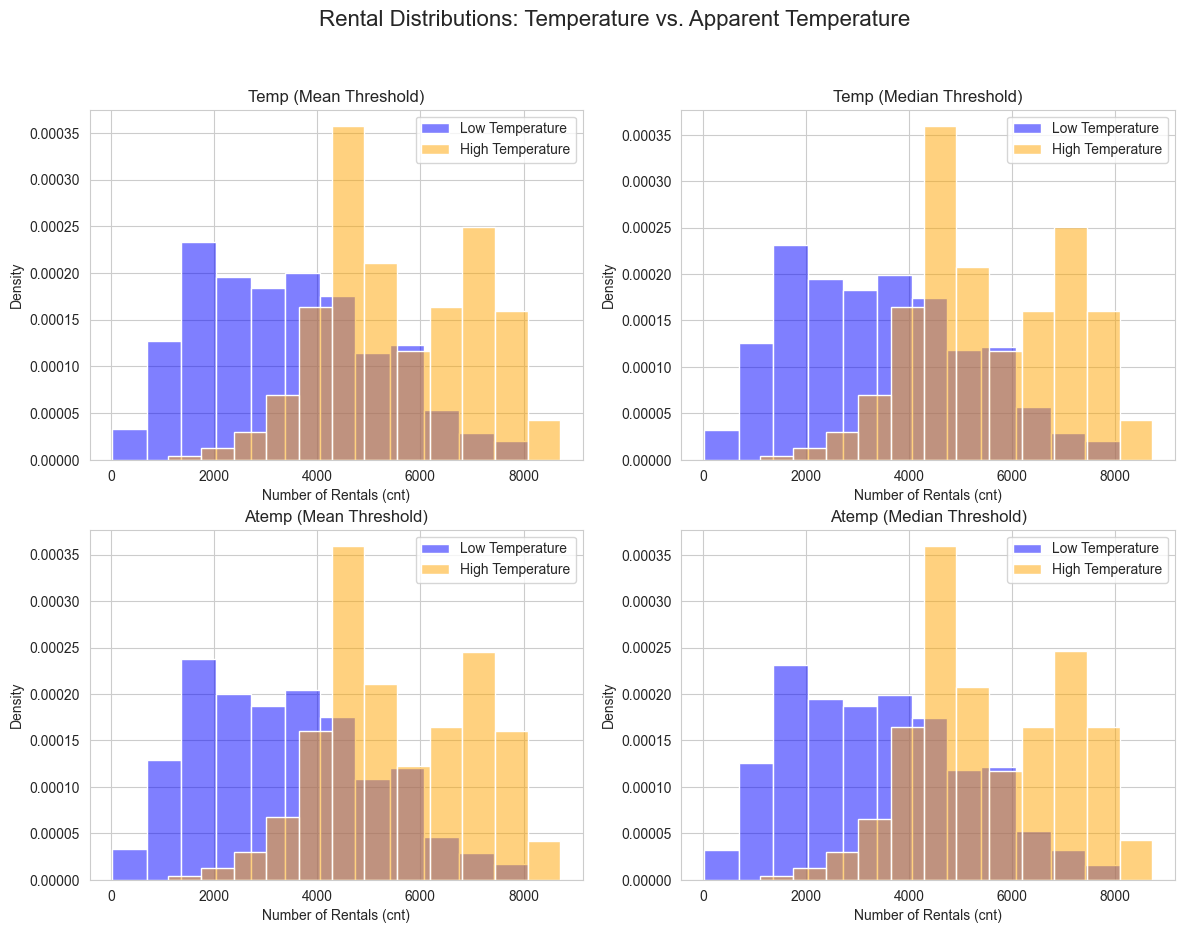

In [54]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Rental Distributions: Temperature vs. Apparent Temperature', fontsize=16)

configs = [
    (low_temp_mean_t, high_temp_mean_t, "Temp (Mean Threshold)", axes[0, 0]),
    (low_temp_median_t, high_temp_median_t, "Temp (Median Threshold)", axes[0, 1]),
    (low_atemp_mean_t, high_atemp_mean_t, "Atemp (Mean Threshold)", axes[1, 0]),
    (low_atemp_median_t, high_atemp_median_t, "Atemp (Median Threshold)", axes[1, 1])
]

for low_data, high_data, title, ax in configs:
    sns.histplot(low_data, color='blue', label='Low Temperature', stat='density', alpha=0.5, ax=ax)
    sns.histplot(high_data, color='orange', label='High Temperature', stat='density', alpha=0.5, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Number of Rentals (cnt)')
    ax.legend()
plt.show()